# Import and Functions

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import json
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from matplotlib.patches import Patch
import matplotlib as plt
import seaborn as sns
import matplotlib.patches as patches
import matplotlib.lines as lines

# Configure Matplotlib settings for font sizes
plt.rcParams.update({
    'font.size': 14,           # Global font size for the plot
    'axes.titlesize': 18,      # Font size for axis titles
    'axes.labelsize': 16,      # Font size for X and Y axis labels
    'xtick.labelsize': 14,     # Font size for X axis tick labels
    'ytick.labelsize': 14,     # Font size for Y axis tick labels
})


In [2]:
def format_label(label):
    """
    Format a label by capitalizing each word and replacing underscores with spaces.

    Parameters:
    label (str): The input label with underscores.

    Returns:
    str: The formatted label with each word capitalized and underscores replaced by spaces.
    """
    return ' '.join(word.capitalize() for word in label.split('_'))


def format_label_count(dca_id, count):
    """
    Format the label to include the count of events.

    Parameters:
    dca_id (str): The DCA_ID to be formatted.
    count (int): The count of events to be included in the label.

    Returns:
    str: The formatted label including the count of events in parentheses.
    """
    return f'{dca_id.replace("_", " ").title()} ({count})'


def parse_custom_colors(colors_json):
    """
    Parse a JSON string to extract custom color mappings.

    Parameters:
    colors_json (str): A JSON string containing color mappings where keys are color names
                       and values are color codes.

    Returns:
    dict: A dictionary containing color mappings extracted from the JSON string. 
          Returns an empty dictionary if the input JSON string is empty or None.
    """
    # Check if the JSON string is provided
    if colors_json:
        try:
            # Attempt to parse the JSON string into a Python dictionary
            custom_colors = json.loads(colors_json)
        except json.JSONDecodeError:
            # Handle JSON decoding errors (e.g., invalid JSON format)
            print("Error: Invalid JSON format.")
            custom_colors = {}
    else:
        # Default to an empty dictionary if the JSON string is empty or None
        custom_colors = {}

    return custom_colors



def load_data(path):
    """
    Load data from a CSV file into a GeoDataFrame.

    Parameters:
    path (str): The file path to the CSV file containing the data.

    Returns:
    GeoDataFrame: A GeoDataFrame with geometries and set CRS.
    """
    # Step 1: Read the CSV file into a DataFrame
    df = pd.read_csv(path)

    # Step 2: Convert the WKT geometries to Shapely geometries
    df['geometry'] = df['geometry'].apply(wkt.loads)

    # Step 3: Convert the DataFrame to a GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry='geometry')

    # Rename the 'Unnamed: 0' column to 'ID_E'
    gdf = gdf.rename(columns={'Unnamed: 0': 'ID_E'})

    # Set the coordinate reference system (CRS) if it's not already set
    gdf.set_crs(epsg=4326, inplace=True)

    return gdf


def process_and_merge_disturbances(gdf, max_iterations=10):
    """
    Process and merge disturbance polygons based on spatial intersections and attributes.
    This function iteratively merges polygons that intersect and have matching attributes 
    until no more changes are detected or the maximum number of iterations is reached.

    Parameters:
    gdf (GeoDataFrame): The input GeoDataFrame containing disturbance polygons.
    region_8_shape_path (str): Path to the shapefile for the region (not used in this function but included for consistency).
    custom_colors (dict): Dictionary for custom colors in plotting (not used in this function but included for consistency).
    max_iterations (int): Maximum number of iterations for merging. The function will stop if merging does not change the data or if this number is reached.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged disturbances and updated geometries.
    """
    print(f"  Initial number of records: {len(gdf)}")  

    # Keep rows where 'PERCENT_AFFECTED' contains 'Severe' or is NaN
    gdf = gdf[gdf['PERCENT_AFFECTED'].isna() | gdf['PERCENT_AFFECTED'].str.contains("Severe", case=False, na=False)]
    print(f"Number of records after filtering 'PERCENT_AFFECTED' for 'Severe' or keeping NaN: {len(gdf)}")


    # Step 1: Drop unnecessary columns that are not relevant for merging and filtering
    columns_to_drop = [
        'PERCENT_AFFECTED', 'HOST', 'HOST_CODE', 'DCA_CODE', 
        'DAMAGE_TYPE_CODE', 'DAMAGE_TYPE', 'cluster_id'
    ]
    gdf = gdf.drop(columns=columns_to_drop)
    print(f"  Number of records after dropping unnecessary columns: {len(gdf)}")  

    # Step 2: Ensure all geometries are valid
    # Fix invalid geometries by buffering them by zero distance
    gdf['geometry'] = gdf.geometry.apply(lambda geom: geom if geom.is_valid else geom.buffer(0))
    
    iteration = 0
    while iteration < max_iterations:
        print(f"> Iteration {iteration + 1}")

        # Step 3: Perform a spatial join to find intersecting polygons
        # This will find polygons that intersect with each other based on specific attributes
        spatial_intersections_att = gpd.sjoin(
            gdf, gdf, how="left", predicate="intersects", 
            lsuffix="left", rsuffix="right", 
            on_attribute=['DCA_ID', 'SURVEY_YEAR', 'REGION_ID', 'DA_Code_USDA']
        )
        print(f"  Number of intersected records: {len(spatial_intersections_att)}")

        # Step 4: Merge intersecting polygons based on 'ID_E_right' and then 'ID_E_left'
        merged_by_right = spatial_intersections_att.dissolve(by="ID_E_right", aggfunc="min")
        merged_by_left = merged_by_right.dissolve(by="ID_E_left", aggfunc="min")

        # Step 5: Reset index to bring 'ID_E_left' back as a column and drop unnecessary columns
        merged_data = merged_by_left.reset_index()
        merged_data = merged_data.drop(columns=['index_right'])
        
        # Step 6: Rename 'ID_E_left' to 'ID_E' and renumber the ID_E column
        merged_data = merged_data.rename(columns={'ID_E_left': 'ID_E'})
        merged_data['ID_E'] = range(len(merged_data))
        merged_data = merged_data.reset_index(drop=True)

        # Step 7: Check if merging has changed the data
        # If the number of records remains the same, stop the iterations
        if len(merged_data) == len(gdf):
            print(">> No more changes detected, stopping iterations.")
            break
        
        # Update the GeoDataFrame for the next iteration
        gdf = merged_data
        iteration += 1

    print(f"   Final number of merged records: {len(merged_data)}")

    return merged_data


def remove_overlapping_entries(df, year_column='SURVEY_YEAR', geometry_column='geometry', year_range=5):
    """
    Remove entries from a GeoDataFrame that overlap spatially within a specified temporal window.

    Parameters:
    df (GeoDataFrame): The input GeoDataFrame containing the data.
    year_column (str): The name of the column containing the survey year.
    geometry_column (str): The name of the column containing the geometry data.
    year_range (int): The number of years before and after the current year to check for overlaps.

    Returns:
    GeoDataFrame: A GeoDataFrame with overlapping entries removed.
    """
    # Create a copy of the GeoDataFrame to avoid modifying the original data
    df = df.copy()
    overlapping_indices = set()

    # Iterate over each row with a progress bar to check for spatial overlaps
    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc=f"Removing overlapping elements within ±{year_range} years"):
        current_year = row[year_column]
        current_geometry = row[geometry_column]

        # Define the time window for checking overlaps
        time_window = (df[year_column] >= (current_year - year_range)) & (df[year_column] <= (current_year + year_range))

        # Identify spatial overlaps within the defined time window
        spatial_overlaps = df.loc[time_window & df[geometry_column].intersects(current_geometry)]

        # If more than one entry overlaps, add their indices to the set of overlapping indices
        if len(spatial_overlaps) > 1:
            overlapping_indices.add(index)
            overlapping_indices.update(spatial_overlaps.index)

    # Drop the overlapping rows from the GeoDataFrame
    df_cleaned = df.drop(index=overlapping_indices)
    
    return df_cleaned

def keep_overlapping_entries(df, id_column='ID_E', year_column='SURVEY_YEAR', geometry_column='geometry', year_range=1):
    """
    Keep entries in a GeoDataFrame that overlap spatially within a ±`year_range` year temporal window.
    Adds a new column 'ID_O' containing the IDs of overlapping entries.

    Parameters:
    df (GeoDataFrame): The input GeoDataFrame containing the data.
    id_column (str): Name of the column containing unique IDs (e.g., 'ID_E').
    year_column (str): Name of the column containing the survey year.
    geometry_column (str): Name of the column containing geometry data.
    year_range (int): The number of years before and after the current year to check for overlaps.

    Returns:
    GeoDataFrame: A GeoDataFrame with overlapping entries and a new column 'ID_O' listing the IDs of overlapping elements.
    """
    df = df.copy()
    df['ID_O'] = None  # Initialize the 'ID_O' column to store overlapping IDs
    
    # Iterate over each row with a progress bar to check for spatial overlaps
    for index, row in tqdm(df.iterrows(), total=df.shape[0], desc=f"Keeping overlaps within ±{year_range} years"):
        current_year = row[year_column]
        current_geom = row[geometry_column]
        current_id = row[id_column]
        
        # Define the time window for checking overlaps
        time_window = (df[year_column] >= (current_year - year_range)) & (df[year_column] <= (current_year + year_range))

        # Identify spatial overlaps within the time window
        spatial_overlaps = df.loc[time_window & df[geometry_column].intersects(current_geom)]

        # Exclude the current row from the overlaps
        spatial_overlaps = spatial_overlaps[spatial_overlaps[id_column] != current_id]

        # If overlaps are found, update the 'ID_O' column with overlapping IDs
        if not spatial_overlaps.empty:
            df.at[index, 'ID_O'] = spatial_overlaps[id_column].tolist()

    # Return only the rows where there is an overlap (i.e., 'ID_O' is not None)
    return df.dropna(subset=['ID_O'])

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlapping entries to determine the longest duration of overlap 
    and count the unique DCA_IDs associated with each entry.

    Parameters:
    gdf_overlap (GeoDataFrame): DataFrame containing overlapping entries.
    id_col (str): Column name for unique IDs (e.g., 'ID_E').
    year_col (str): Column name for the survey year.
    dca_id_col (str): Column name for the DCA_ID.

    Returns:
    GeoDataFrame: Updated DataFrame with columns for longest duration, DCA_ID count, and DCA_ID list.
    """
    # Initialize new columns for results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Analyze each entry with overlaps
    for idx, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Select rows with overlapping IDs
            overlap_data = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate longest duration (max year - min year)
            duration = overlap_data[year_col].max() - overlap_data[year_col].min() + 1
            
            # Get the unique DCA_IDs and their count
            dca_ids = overlap_data[dca_id_col].tolist()
            dca_id_count = len(dca_ids)
            
            # Update the current row with results
            gdf_overlap.at[idx, 'Longest_Duration'] = duration
            gdf_overlap.at[idx, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[idx, 'DCA_ID_List'] = dca_ids

    return gdf_overlap

def analyze_overlaps(gdf_overlap, id_col='ID_E', year_col='SURVEY_YEAR', dca_id_col='DCA_ID'):
    """
    Analyze overlapping entries to determine the longest duration of overlap 
    and count the unique DCA_IDs associated with each entry.

    Parameters:
    gdf_overlap (GeoDataFrame): DataFrame containing overlapping entries.
    id_col (str): Column name for unique IDs (e.g., 'ID_E').
    year_col (str): Column name for the survey year.
    dca_id_col (str): Column name for the DCA_ID.

    Returns:
    GeoDataFrame: Updated DataFrame with columns for longest duration, DCA_ID count, and DCA_ID list.
    """
    # Initialize new columns for results
    gdf_overlap['Longest_Duration'] = None
    gdf_overlap['DCA_ID_Count'] = None
    gdf_overlap['DCA_ID_List'] = None

    # Analyze each entry with overlaps
    for idx, row in tqdm(gdf_overlap.iterrows(), total=gdf_overlap.shape[0], desc="Analyzing overlaps"):
        overlap_ids = row['ID_O']
        
        if overlap_ids:
            # Select rows with overlapping IDs
            overlap_data = gdf_overlap[gdf_overlap[id_col].isin(overlap_ids)]
            
            # Calculate longest duration (max year - min year)
            duration = overlap_data[year_col].max() - overlap_data[year_col].min() + 1
            
            # Get the unique DCA_IDs and their count
            dca_ids = overlap_data[dca_id_col].tolist()
            dca_id_count = len(dca_ids)
            
            # Update the current row with results
            gdf_overlap.at[idx, 'Longest_Duration'] = duration
            gdf_overlap.at[idx, 'DCA_ID_Count'] = dca_id_count
            gdf_overlap.at[idx, 'DCA_ID_List'] = dca_ids

    return gdf_overlap


def analyze_and_enrich_overlaps(df, year_col='SURVEY_YEAR', id_col='ID_E', dca_col='DCA_ID'):
    """
    Explode the 'ID_O' column and enrich the DataFrame with 'O_Year', 'O_DCA_ID', and year differences.

    Parameters:
    df (GeoDataFrame): GeoDataFrame containing overlap information in 'ID_O'.
    id_col (str): Column name for unique IDs.
    year_col (str): Column name for the survey year.
    dca_col (str): Column name for DCA_ID.

    Returns:
    GeoDataFrame: Enriched DataFrame with 'O_Year', 'O_DCA_ID', and 'O_Y_diff'.
    """
    # Explode 'ID_O' into individual rows and drop unnecessary columns
    exploded_df = df.explode('ID_O').drop(columns=['Longest_Duration', 'DCA_ID_Count', 'DCA_ID_List'])

    # Create lookup dictionaries for years and DCA_IDs
    year_lookup = df.set_index(id_col)[year_col].to_dict()
    dca_lookup = df.set_index(id_col)[dca_col].to_dict()

    # Map 'ID_O' to 'O_Year' and 'O_DCA_ID' using lookup dictionaries
    exploded_df['O_Year'] = exploded_df['ID_O'].map(year_lookup)
    exploded_df['O_DCA_ID'] = exploded_df['ID_O'].map(dca_lookup)

    # Calculate year difference between 'O_Year' and current 'SURVEY_YEAR'
    exploded_df['O_Y_diff'] = exploded_df['O_Year'] - exploded_df[year_col]

    return exploded_df


# def filter_disturbance_data(enriched_df, excluded_dca_types, start_year=2015, end_year=2020):
#     """
#     Filter disturbance data by year range, excluded DCA_ID types, and mismatches between DCA_ID and O_DCA_ID.
    
#     Parameters:
#     - enriched_df: DataFrame with enriched disturbance data.
#     - excluded_dca_types: List of DCA_ID types to exclude.
#     - start_year: Start of the year range.
#     - end_year: End of the year range.

#     Returns:
#     - filtered_df_cleaned: DataFrame after all filters.
#     - filtering_summary: Summary of the filtering process.
#     """
#     # Filter by year range
#     df_filtered = enriched_df[(enriched_df['SURVEY_YEAR'] > start_year) & (enriched_df['SURVEY_YEAR'] <= end_year)].copy()
    
#     # Exclude specified DCA_ID types
#     initial_count = len(df_filtered)
#     df_filtered = df_filtered[~df_filtered['DCA_ID'].isin(excluded_dca_types)]
#     rows_dropped_dca = initial_count - len(df_filtered)
    
#     # Find entries with mismatches between DCA_ID and O_DCA_ID, excluding NaNs
#     mismatch_ids = df_filtered[
#         (df_filtered['DCA_ID'] != df_filtered['O_DCA_ID']) &
#         ~(df_filtered['DCA_ID'].isna() | df_filtered['O_DCA_ID'].isna())
#     ]['ID_E'].unique()
    
#     # Find entries with excluded O_DCA_ID types
#     excluded_ids = df_filtered[df_filtered['O_DCA_ID'].isin(excluded_dca_types)]['ID_E'].unique()
    
#     # Combine and exclude mismatched and excluded entries
#     combined_exclusions = np.union1d(mismatch_ids, excluded_ids)
#     df_cleaned = df_filtered[~df_filtered['ID_E'].isin(combined_exclusions)]
#     rows_dropped_overlap = len(df_filtered) - len(df_cleaned)

#     # Provide filtering summary
#     total_events = len(df_cleaned)
#     unique_events = df_cleaned['ID_E'].nunique()
#     summary = (
#         f"    Excluded {rows_dropped_dca} rows with specified DCA_ID types,"
#         f"and {rows_dropped_overlap} additional rows due to mismatches or excluded O_DCA_ID.\n"
#         f"    Unique events | Total events: {unique_events} | {total_events}\n"
#         f"    Remaining overlapping events: {total_events - unique_events}"
#     )
    
#     return df_cleaned, summary


def remove_inverse_matches(df_filtered, with_id_o):
    """
    Removes rows from `df_filtered` where the inverse pair of ID_E and ID_O 
    from removed rows (based on size constraints) are present.

    Parameters:
    - df_filtered: DataFrame that has been filtered according to size constraints.
    - with_id_o: DataFrame with non-null ID_O and within the specified survey year range.
    
    Returns:
    - remaining_df: DataFrame after removing rows with inverse matches.
    - inverse_matches_df: DataFrame containing the inverse matches that were removed.
    """
    # Identify removed rows based on size constraints
    removed_rows = with_id_o[~with_id_o['ID_E'].isin(df_filtered['ID_E'])]
    print(f"Removing Inverse Matches:")

    # Step 2: Extract removed ID_E and ID_O
    removed_id_e = removed_rows['ID_E'].tolist()
    removed_id_o = removed_rows['ID_O'].tolist()

    # Step 3: Find inverse matches in the remaining data
    # Create a set of (ID_E, ID_O) pairs from the removed rows
    removed_pairs = set(zip(removed_rows['ID_E'], removed_rows['ID_O']))

    # Create a DataFrame for remaining rows
    remaining_df = df_filtered.copy()

    # Initialize a list to store rows to remove
    inverse_matches = []

    # Iterate over removed pairs and check for their inverse in the remaining data
    for id_e, id_o in removed_pairs:
        # Find rows in the remaining data where ID_E is ID_O and ID_O is ID_E
        inverse_rows = remaining_df[(remaining_df['ID_E'] == id_o) & (remaining_df['ID_O'] == id_e)]
        if not inverse_rows.empty:
            #print(f" > Inverse matches found for ID_E: {id_e} and ID_O: {id_o}. Removing these rows...")
            inverse_matches.append((id_e, id_o))

    # Convert inverse_matches to DataFrame
    inverse_matches_df = pd.DataFrame(inverse_matches, columns=['ID_E', 'ID_O'])

    # Remove inverse matches from the remaining DataFrame
    for id_e, id_o in inverse_matches:
        remaining_df = remaining_df[~((remaining_df['ID_E'] == id_o) & (remaining_df['ID_O'] == id_e))]

    # Optional: Print details of removed rows for verification
    if not inverse_matches_df.empty:
        print(f"   > Removed rows with inverse matches: - {len(inverse_matches_df)}")
        #print(inverse_matches_df)

      # Print results
    print(f"   = {len(remaining_df)}")


    return remaining_df, inverse_matches_df

def filter_time(original_data, start_year, end_year):
    """
    Filters the original data based on the survey year, removes inverse matches,
    excludes elements with certain criteria, and returns the final DataFrame.

    Parameters:
    - original_data: DataFrame with the original data.
    - start_year: The start year for filtering.
    - end_year: The end year for filtering.

    Returns:
    - final_df: The filtered and cleaned DataFrame.
    """
    
    
    print(f"DataFrame before excluding temporal outlieres: {len(original_data)}")

    # Filter data based on survey year
    filtered_df = original_data[(original_data['SURVEY_YEAR'] > start_year) & (original_data['SURVEY_YEAR'] <= end_year)].copy()

      # Identify removed rows based on size constraints
    removed_rows = original_data[~original_data['ID_E'].isin(filtered_df['ID_E'])]
    print(f"    - {len(removed_rows)}")

    print(f"    = {len(filtered_df)}")

    # Remove inverse matches
    remaining_df, inverse_matches_df = remove_inverse_matches(filtered_df, original_data)

    final_df = remaining_df.copy()
    # Check for elements with O_Year less than start_year
    elements_with_old_years = remaining_df[remaining_df['O_Year'] < start_year]
    
    if not elements_with_old_years.empty:
        print(f"There are {len(elements_with_old_years)} elements where O_Year is less than {start_year}.")
        
        # Identify ID_E values where O_Year is less than start_year
        id_e_to_exclude = elements_with_old_years['ID_E'].unique()
        
        # Filter out rows with these ID_E values from the remaining DataFrame
        filtered_df = remaining_df[~remaining_df['ID_E'].isin(id_e_to_exclude)]

        final_df, _ = remove_inverse_matches(filtered_df, remaining_df)
        print(f"DataFrame after excluding rows with O_Year < {start_year}: {len(final_df)}\n")
    else:
        print(f"There are no elements where O_Year is less than {start_year}.\n")

    return final_df


def filter_disturbance_type(original_data, excluded_dca_types):
    """
    Filters the original data based on excluded disturbance types, removes inverse matches,
    and returns the final cleaned DataFrame.

    Parameters:
    - original_data: DataFrame with the original data.
    - excluded_dca_types: List of disturbance types to be excluded.

    Returns:
    - final_df: The filtered and cleaned DataFrame.
    """
    print(f"DataFrame before excluding disturbance types: {len(original_data)}")
    # Step 1: Filter out rows where 'DCA_ID' is in excluded_dca_types
    filtered_df = original_data[~original_data['DCA_ID'].isin(excluded_dca_types)].copy()

    # Identify removed rows based on size constraints
    removed_rows = original_data[~original_data['ID_E'].isin(filtered_df['ID_E'])]
    print(f"    - {len(removed_rows)}")

    print(f"    = {len(filtered_df)}")

    # Step 2: Remove inverse matches
    remaining_df, inverse_matches_df = remove_inverse_matches(filtered_df, original_data)

    final_df = remaining_df.copy()
    # Step 3: Check for overlapping elements where 'O_DCA_ID' is in excluded_dca_types
    has_overlaps = remaining_df[remaining_df['O_DCA_ID'].isin(excluded_dca_types)]

    if not has_overlaps.empty:
        print(f" > {len(has_overlaps)} elements overlapping with excluded types detected. Removing these elements...")

        # Step 4: Identify ID_E values to be excluded due to overlaps
        id_e_to_exclude = has_overlaps['ID_E'].unique()

        # Step 5: Filter out rows with these 'ID_E' values
        filtered_df = remaining_df[~remaining_df['ID_E'].isin(id_e_to_exclude)]
        
         # Step 6: Remove inverse matches again after the overlap removal
        final_df, _ = remove_inverse_matches(filtered_df, remaining_df)
        print(f" > DataFrame after removing overlapping disturbances: {len(final_df)} \n")
    else:
        print(f" > No elements overlap with excluded types. No removal needed.\n")


    # Step 7: Create a unique identifier 'IDX_D' for each row based on 'DCA_ID', 'SURVEY_YEAR', and row index
    final_df['IDX_D'] = final_df.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)

    return final_df


def filter_size(original_data):


    print(f"DataFrame before filtering by size: {len(original_data)}")
    # Step 1: Filter out rows where 'DCA_ID' is in excluded_dca_types

    gdf_with_area = calculate_area_in_km2(original_data)
    filtered_df = gdf_with_area[gdf_with_area['area_km2'] <= 15]

    # Identify removed rows based on size constraints
    removed_rows = original_data[~original_data['ID_E'].isin(filtered_df['ID_E'])]
    print(f"    - {len(removed_rows)}")

    print(f"    = {len(filtered_df)}")


    remaining_df, inverse_matches_df = remove_inverse_matches(filtered_df, original_data)

    final_df = remaining_df.copy()

    # Identify ID_E values removed due to size constraints
    removed_id_e = set(gdf_with_area[~gdf_with_area['ID_E'].isin(remaining_df['ID_E'])]['ID_E'])
    # Check if there are rows where ID_O matches the removed ID_E values
    rows_to_remove = remaining_df[remaining_df['ID_O'].isin(removed_id_e)]

    # Option 1: Remove only the large element and leave the restof the elements in that did overlap with the overlappin there
    # Print the result for verification
    if not rows_to_remove.empty:
        print(f"   > {len(rows_to_remove)} rows where ID_O matches removed ID_E values detected ....")
        
        # Remove these rows from the DataFrame
        filtered_df = remaining_df[~remaining_df['ID_O'].isin(removed_id_e)]
        
        # Step 6: Remove inverse matches again after the overlap removal
        final_df, _ = remove_inverse_matches(filtered_df, remaining_df)

        print(f" > DataFrame after removing rows with ID_O matching removed ID_E values: {len(final_df)}")
    else:
        print(f" > No rows with ID_O matching removed ID_E values. No removal needed.")

    return final_df


def check_values(df):
    # Extract unique ID_E values from gdf_area
    id_e_area = set(df['ID_E'].unique())

    # Extract unique ID_O values from gdf_area
    id_o_filtered = set(df['ID_O'].unique())

    # Find ID_E values that are not in ID_O
    id_e_not_in_o = id_e_area - id_o_filtered

    # Print the result
    if id_e_not_in_o:
        print(f" > ID_E values that are not in ID_O: {len(id_e_not_in_o)}")
        for id_e in id_e_not_in_o:
            print(f"    ID_E: {id_e}")
    else:
        print(f" > All ID_E values have corresponding ID_O values in df_filtered.")


    id_o_not_in_e = id_o_filtered - id_e_area

    # Print the result
    if id_o_not_in_e:
        print(f" > ID_O values that are not in ID_E: {len(id_o_not_in_e)}")
        for id_o in id_o_not_in_e:
            print(f"    ID_O: {id_o}")
    else:
        print(f" > All ID_O values have corresponding ID_E values in df_filtered.")


def filter_mismatch(original_data):
    """
    Filters out rows where 'DCA_ID' and 'O_DCA_ID' do not match and returns the updated DataFrame without mismatches.
    
    Parameters:
    - original_data: DataFrame containing the original data.
    
    Returns:
    - filtered_data: DataFrame with mismatches removed.
    - mismatch_ids: DataFrame containing the rows that were identified as mismatches.
    """

    print(f"DataFrame before filtering by same DCA: {len(original_data)}")
    
    # Step 1: Identify mismatch IDs
    mismatch_ids = original_data[
        (original_data['DCA_ID'] != original_data['O_DCA_ID']) &
        ~(original_data['DCA_ID'].isna() | original_data['O_DCA_ID'].isna())
    ]
    print(f"    - {len(mismatch_ids)} mismatched rows identified")
    
    # Step 2: Filter out mismatched IDs from the original DataFrame
    filtered_data = original_data[
        ~original_data.index.isin(mismatch_ids.index)
    ]
    print(f"    = {len(filtered_data)} rows after removing mismatches")
    
    return filtered_data


def filter_disturbance_data(data, excluded_dca_types, start_year=2015, end_year=2020):
    
    # Step 1: Filter the non-overlapping elements (where ID_O is null)
    without_id_o = data[data['ID_O'].isnull()]
    print(f"DataFrame values without intersections: {len(without_id_o)}")
    # Filter for timespan
    df_filtered = without_id_o[(without_id_o['SURVEY_YEAR'] > start_year) & (without_id_o['SURVEY_YEAR'] <= end_year)].copy()
    print(f"DataFrame filtered for timespan: {len(df_filtered)}")
    # Filter out excluded disturbance types
    df_filtered = df_filtered[~df_filtered['DCA_ID'].isin(excluded_dca_types)]
    print(f"DataFrame filtered for disturbance types: {len(df_filtered)}")
    # Generate unique identifier for each row
    df_filtered['IDX_D'] = df_filtered.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)
    # Filter by area size
    gdf_with_area = calculate_area_in_km2(df_filtered)
    gdf_area = gdf_with_area[gdf_with_area['area_km2'] <= 15]
    print(f"DataFrame filtered for size: {len(gdf_area)}")
    

    # Step 2: Filter the overlapping elements (where ID_O is not null)
    with_id_o = data[data['ID_O'].notnull()]
    # Apply various filtering functions
    filtered_time_gdf = filter_time(with_id_o, start_year, end_year)
    filtered_type_gdf = filter_disturbance_type(filtered_time_gdf, excluded_dca_types)
    filtered_size_gdf = filter_size(filtered_type_gdf)
    filtered_mismatch_gdf = filter_mismatch(filtered_size_gdf)
    
    if isinstance(gdf_area, gpd.GeoDataFrame) and isinstance(filtered_mismatch_gdf, gpd.GeoDataFrame):
        combined_gdf = pd.concat([gdf_area, filtered_mismatch_gdf], ignore_index=True)
    else:
        raise TypeError("Both DataFrames must be GeoDataFrames")

    # Convert back to GeoDataFrame if necessary
    combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry='geometry')  # Make sure to specify the geometry column

    print(f"Combined DataFrame size: {len(combined_gdf)}")
    
    return combined_gdf


def calculate_area_in_km2(gdf):
    """
    Calculate the area of each polygon in the GeoDataFrame in square kilometers.

    Parameters:
    gdf (GeoDataFrame): GeoDataFrame with geometries in WKT format.

    Returns:
    GeoDataFrame: GeoDataFrame with an added column for area in square kilometers.
    """
    # Step 1: Set target CRS to EPSG:4326
    target_crs = 'EPSG:4326'
    gdf = gdf.to_crs(target_crs)
    
    # Step 2: Reproject to a CRS with meters (e.g., EPSG:3857)
    projected_gdf = gdf.to_crs('EPSG:3857')
    
    # Step 3: Calculate the area in square meters
    projected_gdf['area_m2'] = projected_gdf.geometry.area
    
    # Step 4: Convert the area to square kilometers
    projected_gdf['area_km2'] = projected_gdf['area_m2'] / 1e6
    
    # Step 5: Assign the calculated area to a new column in the original GeoDataFrame
    gdf['area_km2'] = projected_gdf['area_km2']
    
    # Step 6: Return the modified GeoDataFrame
    return gdf


In [3]:
def plot_regions_disturbances(disturbance_gdf, filepath, output_file, custom_colors, region_nr):

    usa = gpd.read_file(filepath)
    country = usa[usa.REGION == region_nr]
    
    region = country.explode()[0:1]  # Adjust this line as needed to select region 8
    
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(12, 12))  # Adjust size as needed

    # Create legend handles
    handles = []

    # Plot the boundaries of intersected geometries with custom colors
    for dca_id, color in custom_colors.items():
        subset = disturbance_gdf[disturbance_gdf['DCA_ID'] == dca_id]
        subset = subset[subset.is_valid]
         # Check if subset is not empty
        if not subset.empty:
            # Plot directly without using .boundary
            subset.plot(ax=ax, edgecolor=color, linewidth=0.5, linestyle='-', zorder=2)
            # Add handle for legend
            handles.append(Patch(color=color, label=format_label_count(dca_id, len(subset))))

    # Plot the boundary of the selected region
    region.boundary.plot(ax=ax, color='black', linewidth=0.5, linestyle='--', zorder=3) 
    # Add handle for region boundary with dotted border
     # Add handle for region boundary with transparent box and red dotted border
    handles.append(Patch(facecolor='none', edgecolor='black', linestyle='--', linewidth=1, 
                          label=f'Region {region_nr} Boundary',))


    # Customize the plot appearance
    ax.set_title(f'IDS Disturbances within Region {region_nr}', fontsize=18, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='--', alpha=0.7)  # Add grid lines for better readability

    # Set the aspect ratio of the plot to be equal
    ax.set_aspect('equal')

    # Add the legend with all handles
    ax.legend(handles=handles, loc='best', fontsize=14)

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')  
    plt.show()


In [4]:
def reset_id_e(gdf):
    # Reset ID_E to a new sequential index starting from 0
    gdf = gdf.reset_index(drop=True)
    gdf['ID_E'] = gdf.index
    return gdf

# Main and Testing

In [5]:
"""
Main function to set up the environment, load file paths, and get custom color mappings and calls functions
"""

print("Set up environment variables ...")
# Load environment variables from a .env file
env_path = Path('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/environment/.env')
load_dotenv(dotenv_path=env_path)

os.environ['REGION'] = '8'  # Set it directly in Python for testing
region = os.getenv('REGION')
print(f"Working on USDA Region {region} ...")
region_id=str(region).zfill(2)
# Define file paths using environment variables
region_shape_path = f"{os.getenv('REGION_SHAPE')}S_USA.AdministrativeRegion.shp"
ids_region_file_path = f"{os.getenv('IDS_REGIONS')}CONUS_Region{region}_dissolved.csv"
file_output_path = f"{os.getenv('RESULTS')}/region{region_id}_dca_filtered_ids_usda_polygons.shp"
figure_output_path = f"{os.getenv('FIGURES')}/p1_f1_disturbances_region_{region_id}.png"

# Retrieve and parse custom color settings from environment variables
custom_colors_json = os.getenv('COLORS')
custom_colors = parse_custom_colors(custom_colors_json)


Set up environment variables ...
Working on USDA Region 8 ...


Step 1: Loading CSV file for Region 08...
Step 2: Processing and cleaning disturbance data...
  Initial number of records: 68916
Number of records after filtering 'PERCENT_AFFECTED' for 'Severe' or keeping NaN: 40111
  Number of records after dropping unnecessary columns: 40111
> Iteration 1
  Number of intersected records: 101959
> Iteration 2
  Number of intersected records: 50345
> Iteration 3
  Number of intersected records: 30689
> Iteration 4
  Number of intersected records: 27968
> Iteration 5
  Number of intersected records: 27770
>> No more changes detected, stopping iterations.
   Final number of merged records: 27770
Step 3: Removing temporal and spatial overlaps...


Removing overlapping elements within ±5 years: 100%|██████████| 27770/27770 [04:11<00:00, 110.37it/s]


> Number of records after removing overlaps: 23681
Step 4: Identifying entries with temporal and spatial overlaps within ±1 year...


Keeping overlaps within ±5 years: 100%|██████████| 27770/27770 [04:30<00:00, 102.84it/s]


> Number of records with detected overlaps: 4089
Step 5: Analyzing overlaps...


Analyzing overlaps: 100%|██████████| 4089/4089 [00:04<00:00, 973.57it/s] 


Step 6: Merging datasets...
Step 7: Exploding geometries and enriching data...
Step 8: Filtering disturbances between 2016 and 2020...
DataFrame values without intersections: 23681
DataFrame filtered for timespan: 2472
DataFrame filtered for disturbance types: 2095
DataFrame filtered for size: 2056
DataFrame before excluding temporal outlieres: 12698
    - 11852
    = 846
Removing Inverse Matches:
   > Removed rows with inverse matches: - 128
   = 718
There are no elements where O_Year is less than 2015.

DataFrame before excluding disturbance types: 718
    - 13
    = 705
Removing Inverse Matches:
   > Removed rows with inverse matches: - 9
   = 696
 > No elements overlap with excluded types. No removal needed.

DataFrame before filtering by size: 696
    - 226
    = 470
Removing Inverse Matches:
   > Removed rows with inverse matches: - 118
   = 352
 > No rows with ID_O matching removed ID_E values. No removal needed.
DataFrame before filtering by same DCA: 352
    - 2 mismatched row

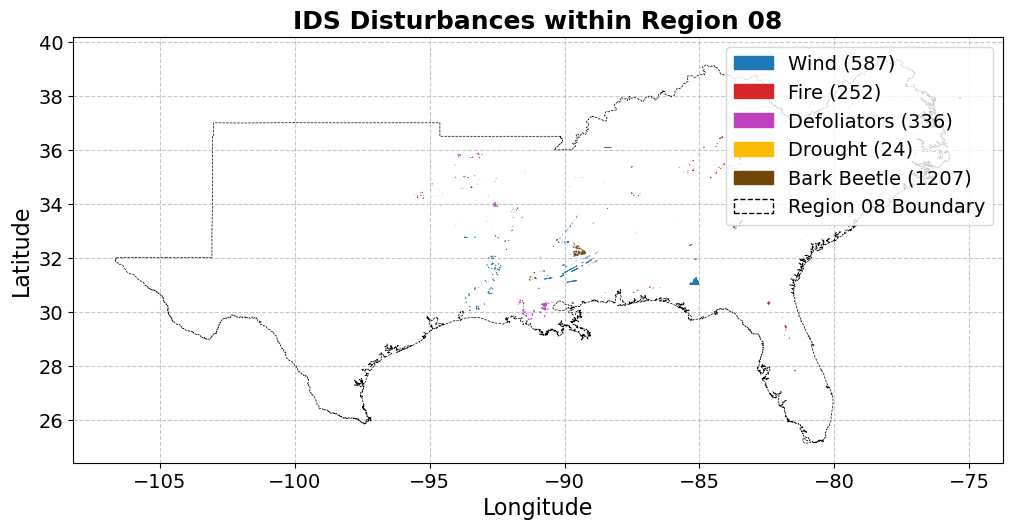

Step 13: Saving results to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//region08_dca_filtered_ids_usda_polygons.shp ...
Results successfully saved to: /net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results//region08_dca_filtered_ids_usda_polygons.shp


In [294]:
print(f"Step 1: Loading CSV file for Region {region_id}...") 
gdf = load_data(ids_region_file_path)

print("Step 2: Processing and cleaning disturbance data...")
merged_gdf = process_and_merge_disturbances(gdf)
#reset_gdf = reset_id_e(merged_gdf)

print("Step 3: Removing temporal and spatial overlaps...")
gdf_no_overlap = remove_overlapping_entries(reset_gdf, year_range=5)
print(f"> Number of records after removing overlaps: {len(gdf_no_overlap)}")

print("Step 4: Identifying entries with temporal and spatial overlaps within ±1 year...")
gdf_overlap = keep_overlapping_entries(reset_gdf, year_range=5)
print(f"> Number of records with detected overlaps: {len(gdf_overlap)}")

# Step 5: Analyzing overlaps
print("Step 5: Analyzing overlaps...")
gdf_overlap_analyzed = analyze_overlaps(gdf_overlap)

# Step 6: Merging datasets with and without overlaps
print("Step 6: Merging datasets...")
merged_gdf = gpd.GeoDataFrame(pd.concat([gdf_no_overlap, gdf_overlap_analyzed]))

# Step 7: Exploding geometries and enriching data with DCA and year information
print("Step 7: Exploding geometries and enriching data...")
enriched_df = analyze_and_enrich_overlaps(merged_gdf)

# Step 8: Filter disturbance data
print("Step 8: Filtering disturbances between 2016 and 2020...")
excluded_dca_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
filtered_df_cleaned = filter_disturbance_data(enriched_df, excluded_dca_types, start_year=2015, end_year=2020)
#print(filtering_summary)

# # Step 9: Generate new index_usda values
# print("Step 9: Generating new index_usda values...")
# filtered_df_cleaned['IDX_D'] = filtered_df_cleaned.apply(
#     lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1
# )

# # Step 10: Calculate area in km²
# print("Step 10: Calculating area in km²...")
# gdf_with_area = calculate_area_in_km2(filtered_df_cleaned)

# # Step 11: Remove elements larger than 15 km²
# print("Step 11: Removing elements larger than 15 km²...")
# gdf_area = gdf_with_area[gdf_with_area['area_km2'] <= 15]

# Output summary
total_elements = len(filtered_df_cleaned)
unique_events = len(filtered_df_cleaned['ID_E'].unique())
overlapping_events = total_elements - unique_events

print(f"Number of elements after removing large areas: {total_elements}")
print(f"    Unique events | Total events: {unique_events} | {total_elements}")
print(f"    Remaining overlapping events: {overlapping_events}")

# Rename columns to avoid issues with field name normalization
print("Renaming columns...")
column_renames = {
    'SURVEY_YEAR': 'SURVEY_Y',
    'DA_Code_USDA': 'DA_C_USDA'
}
data = filtered_df_cleaned.rename(columns=column_renames)


# Step 12: Plot the final results
print("Step 12: Plotting the final results...")
plot_regions_disturbances(
    data, 
    region_shape_path, 
    output_file= figure_output_path, 
    custom_colors=custom_colors,
    region_nr= region_id
)

# Step 13: Save the final GeoDataFrame to a shapefile
print(f"Step 13: Saving results to: {file_output_path} ...")
data.to_file(file_output_path, index=False)
print(f"Results successfully saved to: {file_output_path}")


In [295]:
ids = gpd.read_file('/net/projects/forexd/WP1/02_ImprovedLabels/Scripts/ForExD-WP1-P1/results/region08_dca_filtered_ids_usda_polygons.shp')

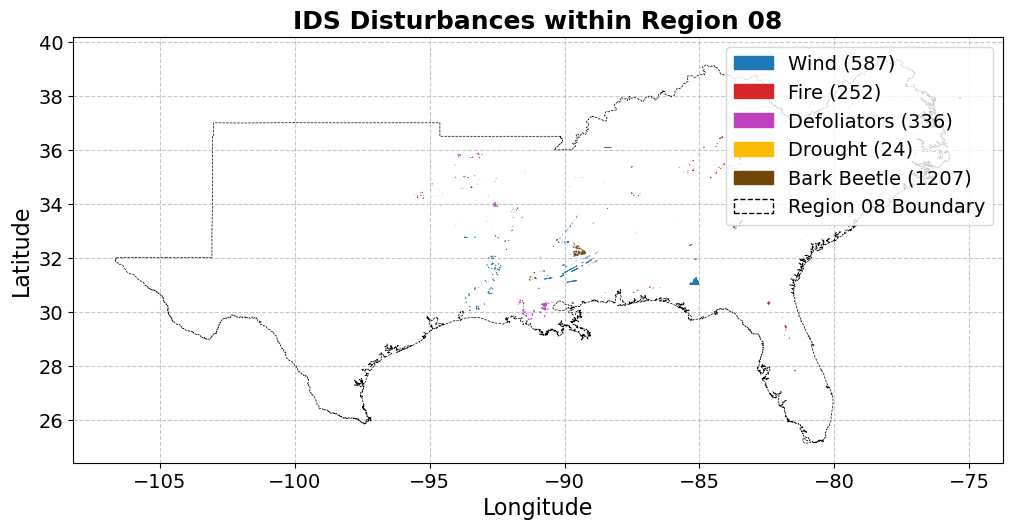

In [296]:
plot_regions_disturbances(
    ids, 
    region_shape_path, 
    output_file= None, 
    custom_colors=custom_colors,
    region_nr= region_id
)

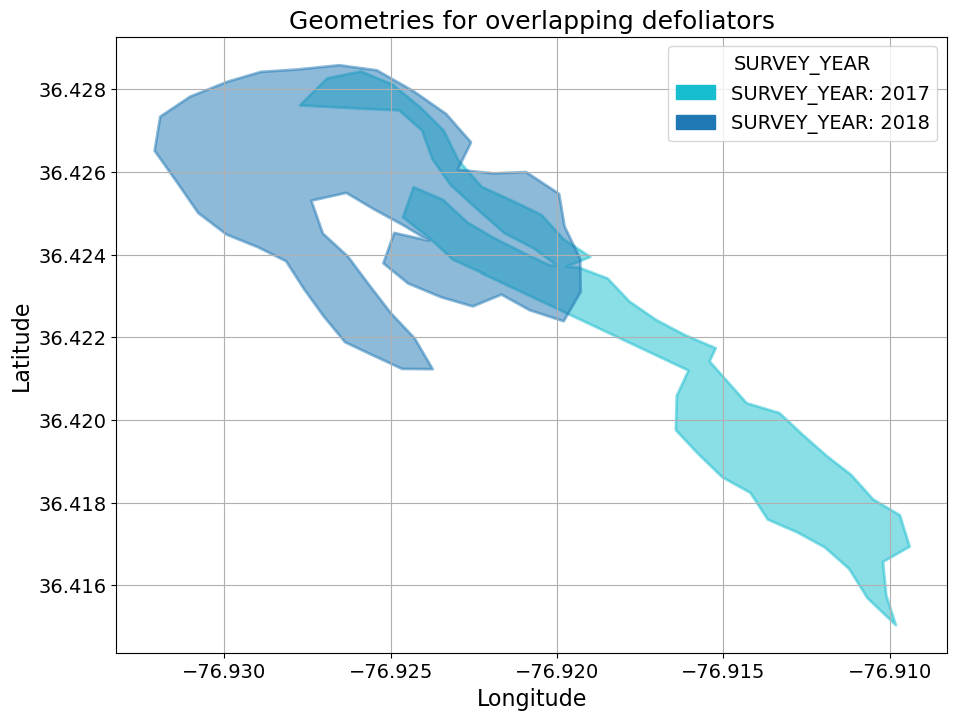

In [165]:
# Extract unique DCA_IDs for the title
dca_ids = combined_gdf['DCA_ID'].unique()
dca_ids_str = ', '.join(map(str, dca_ids))

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Create a colormap and reverse it
cmap = plt.get_cmap('tab10')  # Or any other colormap you prefer
cmap_reversed = cmap.reversed()
norm = plt.Normalize(combined_gdf['SURVEY_YEAR'].min(), combined_gdf['SURVEY_YEAR'].max())

# Get sorted SURVEY_Y values
sorted_survey_y = sorted(combined_gdf['SURVEY_YEAR'].unique())

# Plot each subset of data with face color and edge color
for survey_y in sorted_survey_y:
    subset = combined_gdf[combined_gdf['SURVEY_YEAR'] == survey_y]
    color = cmap_reversed(norm(survey_y))
    subset.plot(ax=ax, 
                edgecolor=color,  # Use the colormap for edgecolor
                facecolor=color,  # Set facecolor to the same color for visibility
                linewidth=2,  # Thicker boundary line
                alpha=0.5,  # Semi-transparent fill for better visibility
                label=f'SURVEY_YEAR: {survey_y}')  # Add a label for the legend

# Create legend handles manually, sorted by SURVEY_Y
legend_handles = [Patch(color=cmap_reversed(norm(survey_y)), label=f'{survey_y}') for survey_y in sorted_survey_y]

# Add legend to plot
ax.legend(handles=legend_handles, title='SURVEY_YEAR', loc='best')

# Set plot title and labels
ax.set_title(f'Geometries for overlapping {dca_ids_str}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True)

plt.show()

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

def get_region_shape_bounds(filepath, region_nr, output_path):
    # Load the shapefile
    usa = gpd.read_file(filepath)
    
    # Filter for the specified region
    country = usa[usa['REGION'] == region_nr]
    
    # Explode multipolygons (if any) and get the first part
    region = country.explode(index_parts=False)[0:1]
    
    # Get the bounding box of the region
    bounds = region.total_bounds  # Returns (x_min, y_min, x_max, y_max)
    
    # Extract values from the bounding box
    x_min, y_min, x_max, y_max = bounds
    
    # Plot the region shape
    fig, ax = plt.subplots(figsize=(8, 8))
    region.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=1)
    
    # Plot the bounding box as a rectangle
    bbox = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         edgecolor='brown', facecolor='none', linewidth=2, linestyle='--')
    ax.add_patch(bbox)
    
    # Plot the bounding box corners with red dots
    ax.scatter([x_min, x_max, x_min, x_max], [y_min, y_min, y_max, y_max], color='red', zorder=5)
    
    # Set axis labels and title
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'Region {region_nr} with Bounding Box')
    
    # Save the figure to the specified output path
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Close the figure to free memory
    
    # Return the bounding box coordinates
    return x_min, y_min, x_max, y_max


Working on USDA Region 9 ...


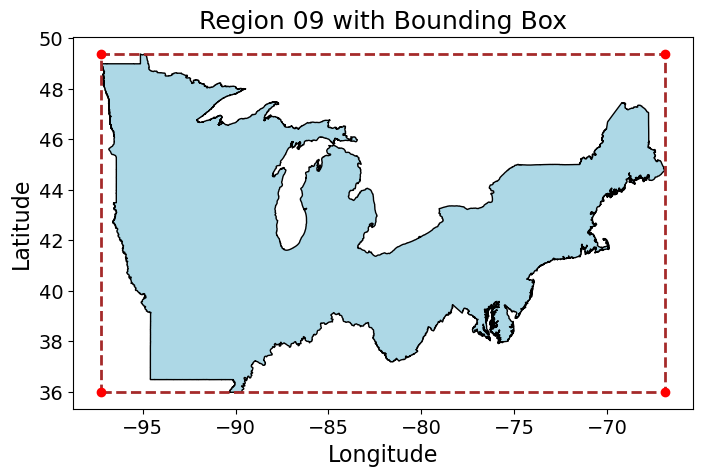

(-97.23919599999999, 35.995682999999985, -66.8861698, 49.38435800000002)

In [19]:
r = os.getenv('REGION')
print(f"Working on USDA Region {region} ...")
r_id=str(r).zfill(2)
# Define file paths using environment variables
region_shape_path = f"{os.getenv('REGION_SHAPE')}S_USA.AdministrativeRegion.shp"

get_region_shape_bounds(region_shape_path, r_id)

# Plot Overlap

In [271]:
# Define the mapping for DCA_IDs
dca_id_mapping = {
    'wind': 'W',
    'bark_beetle': 'BB',
    'fire': 'F',
    'drought': 'D',
    'defoliators': 'DF',
    'other_abiotics': 'OA',
    'other': 'O',
    'other_biotics': 'OB'
}

# Create a DataFrame to store all intersections
all_intersections = []

# Get unique DCA_IDs
unique_dca_ids = gdf['DCA_ID'].explode().unique()
unique_dca_ids

array(['defoliators', 'other_biotic', 'bark_beetle', 'other_abiotic',
       'other', 'fire', 'wind', 'drought'], dtype=object)

In [245]:
import pandas as pd

def generate_intersection_df(gdf):
    """
    Generate a DataFrame with intersection counts for all DCA_IDs, including a DCA_Short column.
    
    Parameters:
    gdf (DataFrame): DataFrame containing the overlap analysis with 'DCA_ID_List' and 'O_Year_diff'.
    
    Returns:
    DataFrame: A DataFrame containing intersections with an additional column for the original DCA_ID and DCA_Short.
    """
    # Define the mapping for DCA_IDs
    dca_id_mapping = {
        'wind': 'W',
        'bark_beetle': 'BB',
        'fire': 'F',
        'drought': 'D',
        'defoliators': 'DF',
        'other_abiotics': 'OA',
        'other': 'O',
        'other_biotics': 'OB'
    }
    
    # Create a DataFrame to store all intersections
    all_intersections = []

    # Get unique DCA_IDs
    unique_dca_ids = gdf['DCA_ID'].explode().unique()

    for target_dca_id in unique_dca_ids:
        # Filter the DataFrame to include only rows where the target_dca_id is in 'DCA_ID_List'
        filtered_df = gdf[gdf['DCA_ID'].apply(lambda x: target_dca_id in x)]
        
        # Create a dictionary to store the counts of intersections, grouped by year difference
        intersection_counts = {}
        
        # Iterate over each filtered row
        for _, row in filtered_df.iterrows():
            dca_ids = row['O_DCA_ID']
            year_diffs = row['O_Y_diff']
            
            # Ensure dca_ids and year_diffs are lists
            if isinstance(dca_ids, str):
                dca_ids = [dca_ids]
            if not isinstance(year_diffs, list):
                year_diffs = [year_diffs]
            
            # Check if lengths are the same
            if len(dca_ids) != len(year_diffs):
                raise ValueError("Mismatch between lengths of dca_ids and year_diffs")
            
            # Process each pair
            for dca_id, year_diff in zip(dca_ids, year_diffs):
                if dca_id not in intersection_counts:
                    intersection_counts[dca_id] = {}
                if year_diff not in intersection_counts[dca_id]:
                    intersection_counts[dca_id][year_diff] = 0
                intersection_counts[dca_id][year_diff] += 1
        
        # Convert the intersection counts to a DataFrame
        plot_data = []
        for dca_id_code, year_diffs in intersection_counts.items():
            for year_diff, count in year_diffs.items():
                plot_data.append({
                    'original_dca_id': target_dca_id, 
                    'DCA_ID': dca_id_code, 
                    'Year Offset': year_diff, 
                    'Count': count
                })
        
        intersection_df = pd.DataFrame(plot_data)
        all_intersections.append(intersection_df)

    # Concatenate all DataFrames into one
    final_df = pd.concat(all_intersections, ignore_index=True)
    
    # Map the DCA_ID and original_dca_id to their short forms using dca_id_mapping
    final_df['DCA_Short'] = final_df['DCA_ID'].map(dca_id_mapping)
    final_df['Original_DCA_Short'] = final_df['original_dca_id'].map(dca_id_mapping)
    
    return final_df


In [175]:
def plot_overlap(df):
    # Define the correct palette based on unique values
    palette_blue = {
        '-1': '#2C5DA6', 
        '0': '#000C7A', 
        '1': '#6FD7E7'
    }

    # Define the desired order for 'Year_Diff'
    year_diff_order = ['-1', '0', '1']

    # Create the catplot
    g = sns.catplot(
        data=df, 
        x="DCA_Short", 
        y="Count", 
        col="original_dca_id", 
        hue="Year Offset",  # Use hue to separate by Year_Diff
        kind="bar",
        saturation=0.7, 
        height=4,
        width=0.9,
        aspect=.6,
        estimator="sum",
        legend='full',
        palette=palette_blue,  # Use the updated palette
        hue_order=year_diff_order  # Set the order for Year_Diff
    )

    # Define a proportional offset factor
    offset_factor = 0.7  # 10% of the bar height

    # Iterate over each subplot to add markers
    for ax in g.axes.flat:
        # Set y-axis to log scale
        ax.set_yscale('log')
        # Add bar labels to all bars
        for container in ax.containers:
            ax.bar_label(container, fontsize=8, label_type='edge', color='black', padding=2)  # Add labels at the edge of the bars


        # Update the title to just show the original_dca_id without the prefix
        tt = ax.get_title().split(" = ")[-1]
        title = ' '.join(word.capitalize() for word in tt.split('_'))
        ax.set_title(title)

        # Find the subset where Year_Diff = 0
        subset = df[(df['Year Offset'] == '0') & (df['original_dca_id'] == tt.lower())]

        # Ensure there is at least one entry
        if not subset.empty:
            # Identify the row with the maximum count
            max_row = subset.loc[subset['Count'].idxmax()]

            x_pos = max_row['DCA_Short']
            y_pos = max_row['Count']
            
            # Find the x position of the bar to place the star marker
            x_ticks = [tick.get_text() for tick in ax.get_xticklabels()]
            x_index = x_ticks.index(x_pos)
            
            # Calculate a proportional offset
            y_limit = ax.get_ylim()[1]  # Get the upper limit of y-axis
            offset = offset_factor * (y_limit / y_pos)  # Proportional offset
            
            # Plot a star marker on top of the bar with a proportional offset
            ax.plot(x_index, y_pos * (1.5 + offset_factor), "*", markersize=10, color="r")

        # Add a single x-axis label under all columns
        plt.subplots_adjust(bottom=0.15)  # Adjust to make space for the label
        g.set_axis_labels(x_var=" ", y_var="Count")

    g.fig.text(0.5, 0.02, 'DCA', ha='center', va='center', fontsize=16)

    # Extract unique DCA_Short and corresponding DCA_ID descriptions
    dca_mapping = {
        'BB': 'Bark Beetle',
        'W': 'Wind',
        'F': 'Fire',
        'D': 'Drought',
        'DF': 'Defoliators'
    }

    # Create legend elements without colored patches
    legend_elements = [lines.Line2D([0], [0], color='black', linestyle='-', linewidth=0, label=f'{key} = {description}')
                    for key, description in dca_mapping.items()]
    # Add the legend to the figure
    g.fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=14)
    # Add a header to the entire plot
    #g.fig.suptitle('Disturbance Interactions per yearly offset', fontsize=26)
    plt.savefig('/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/p1_f9_disturbance_interactions_per_yearly_offset.png', dpi=300, bbox_inches='tight')

    plt.show()


In [273]:
res = generate_intersection_df(filtered_mismatch_gdf)
filtered_res = res[res['Year Offset'] >= 0]
#plot_overlap(res)
filtered_res

,original_dca_id,DCA_ID,Year Offset,Count,DCA_Short,Original_DCA_Short
0,defoliators,defoliators,2.0,17,DF,DF
1,defoliators,defoliators,3.0,5,DF,DF
2,defoliators,defoliators,1.0,19,DF,DF
6,fire,fire,2.0,1,F,F
8,bark_beetle,bark_beetle,1.0,5,BB,BB
10,wind,wind,1.0,128,W,W


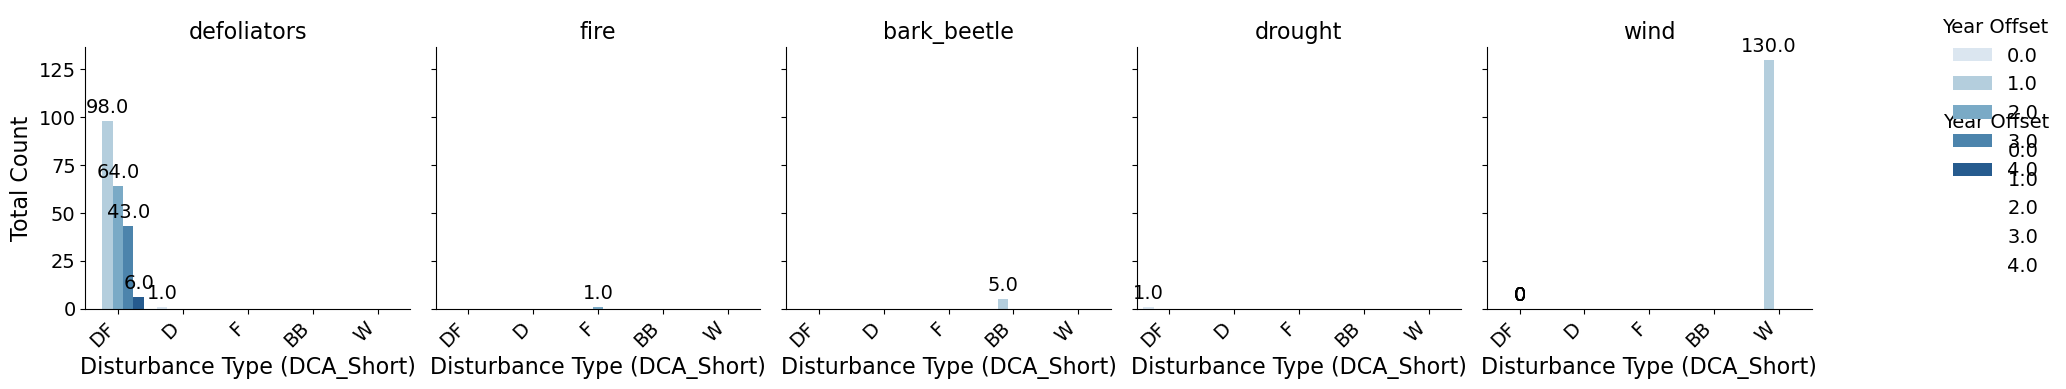

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set your palette and order for Year Offset, adjust as necessary
palette_blue = sns.color_palette("Blues", n_colors=len(df['Year Offset'].unique()))  # Ensure palette length matches unique Year Offset values
year_diff_order = sorted(df['Year Offset'].unique())  # Sort Year Offset values

# Create the catplot
g = sns.catplot(
    data=df, 
    x="DCA_Short", 
    y="Count", 
    col="original_dca_id", 
    hue="Year Offset",  # Use hue to separate by Year Offset
    kind="bar",
    saturation=0.7, 
    height=4,
    aspect=.8,  # Adjust aspect ratio for better spacing
    estimator=sum,  # Sum of counts
    legend='full',
    palette=palette_blue,  # Use the updated palette
    hue_order=year_diff_order  # Set the order for Year Offset
)

# Set titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Disturbance Type (DCA_Short)", "Total Count")
g.set_xticklabels(rotation=45, ha='right')  # Rotate x labels for better readability

# Add data labels over bars
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', 
                    xy=(p.get_x() + p.get_width() / 2, height), 
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', 
                    va='bottom')

# Adjust legend and layout
g.add_legend(title='Year Offset', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
plt.tight_layout()
plt.show()


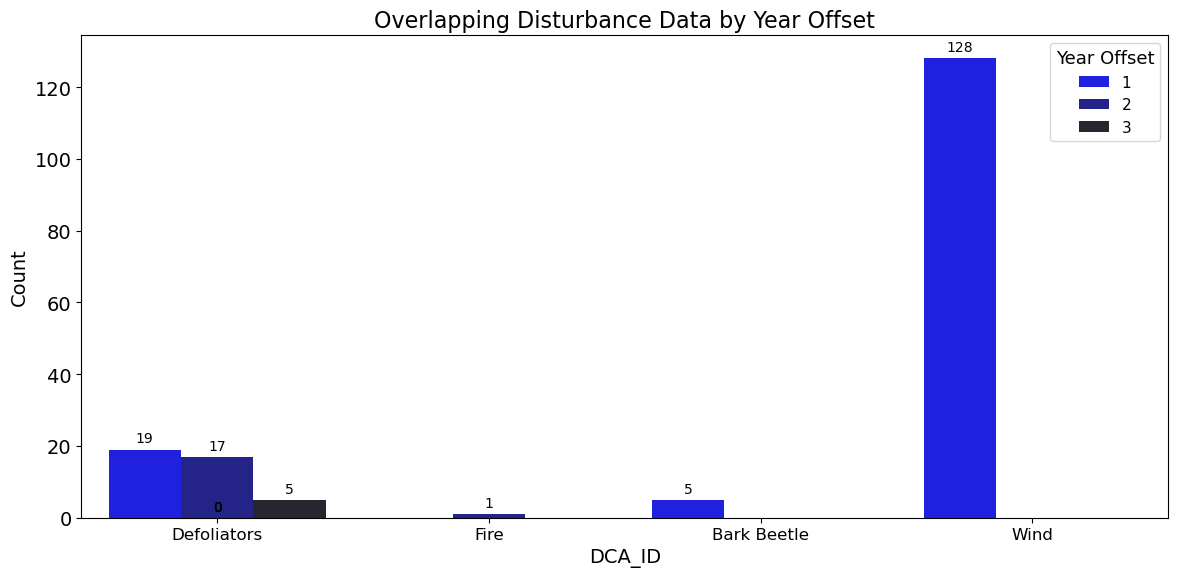

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample DataFrame
data = {
    'original_dca_id': ['defoliators', 'defoliators', 'defoliators', 'fire', 'bark_beetle', 'wind'],
    'DCA_ID': ['defoliators', 'defoliators', 'defoliators', 'fire', 'bark_beetle', 'wind'],
    'Year Offset': [2.0, 3.0, 1.0, 2.0, 1.0, 1.0],
    'Count': [17, 5, 19, 1, 5, 128],
    'DCA_Short': ['DF', 'DF', 'DF', 'F', 'BB', 'W'],
    'Original_DCA_Short': ['DF', 'DF', 'DF', 'F', 'BB', 'W']
}
df = pd.DataFrame(data)

# Define a custom color palette that transitions from dark to light blue
def create_palette(n_colors):
    return sns.dark_palette("blue", n_colors=n_colors, reverse=True)  # Reverse the palette to go from dark to light

# Create the grouped bar plot
plt.figure(figsize=(12, 6))

# Get unique Year Offsets and create a color palette
year_offsets = sorted(df['Year Offset'].unique())
color_palette = create_palette(len(year_offsets))

# Create a grouped bar plot
g = sns.barplot(
    data=df,
    x='DCA_ID',  # X-axis: DCA_ID categories
    y='Count',   # Y-axis: Count of occurrences
    hue='Year Offset',  # Color bars by Year Offset
    palette=color_palette,  # Custom color palette
    estimator='sum'
)

# Annotate bars with counts
for p in g.patches:
    g.annotate(
        f'{int(p.get_height())}',  # Annotation text
        (p.get_x() + p.get_width() / 2., p.get_height()),  # Position
        ha='center', va='center',  # Alignment
        xytext=(0, 8), textcoords='offset points',  # Offset text
        fontsize=10, color='black'  # Font size and color
    )

# Add titles and labels
plt.title('Overlapping Disturbance Data by Year Offset', fontsize=16)
plt.xlabel('DCA_ID', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Format x-axis labels
xticks_labels = [format_label(label) for label in df['DCA_ID'].unique()]
xticks_positions = range(len(xticks_labels))
plt.xticks(ticks=xticks_positions, labels=xticks_labels, fontsize=12)  # Ensure no rotation and set font size

# Adjust legend
handles, labels = g.get_legend_handles_labels()
# Convert labels to integers
labels = [int(float(label)) for label in labels]
g.legend(handles, labels, title='Year Offset', title_fontsize='13', fontsize='11')  # Customize legend

# Final adjustments for layout
plt.tight_layout()

plt.show()
